<h2>Assignment 1</h2>

<table style="width:100%; text-align:left;">
<tr>
<td>

### Student 1  
**Name:** Aakanksha Deshpande  
**Student Id:** 25238088  

</td>

<td>

### Student 2  
**Name:** Vijayalaxmi Hubli  
**Student Id:** 25242017  

</td>
</tr>
</table>


## Task 1: Implement Logistic Regression

In [1]:
# Package imports
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
# Display plots inline
%matplotlib inline

In [3]:
# Sigmoid Function (Activation Function)

def sigmoid(z):
    """
    Implementation of activation function
    Inputs:
    z (linear input)
    Outputs: 
    Binary classification returns probability value between 0 & 1
    """
    return (1 / (1 + (np.exp(-z))))

In [4]:
# Loss function
def compute_loss(y, y_hat):
    """
    Implementation of cross-entropy loss function

    Inputs:
    y = True Label (0 or 1)
    y_hat = Predicted probability (between 0 and 1)

    Output:
    Loss for the classification
    """
    return (- (y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))).item()

In [5]:
# Implementing Logistic Regression Algorithm

def train_logistic_regression(X, Y, alpha, max_iteration, threshold):
    """
    Logistic Regression Learning Algorithm with forward pass and Stochastic Gradient Descent

    Inputs:
    X = training dataset
    Y = target labels
    alpha = learning rate
    max_iteration = no of steps allowed for training
    threshold = stopping criteria

    Outputs:
    w = learned weights
    b = learned bias
    loss = loss calculated at per iteration
    epoch_loss = loss of a single epoch
    """
    #---------------------------------
    # Initialising parameters
    #---------------------------------
    np.random.seed(42)                        # To ensure same results everytime
    stopping = False                          # To exit the while loop once convergence is met
    J_running = 0                             # Represents cumulative loss of an epoch 
    epoch_number = 0                          # To keep a counter of epochs
    J_running_prev = 0                        # Represents previous epoch loss for convergence comparsion
    prev_avg_loss = float("inf")
    iteration = 0                             # To keep a counter of iterations     
    N,m = X.shape                             # N = no: of samples, m = no:of features
    w = np.random.normal(0, 0.01, size=(m,1)) # Small range of w & b choosen to avoid missing minima
    b = 0.01                                 

    #---------------------------------
    # Implementing SGD
    #---------------------------------
    loss = []
    epoch_loss = []
    while not stopping:

        # picking random values from training dataset
        index = np.random.randint(0, N)
        x_i = X[index].reshape(-1,1)
        y_i = Y[index]

        # Implementing Forward propagation stage
        z = np.dot(w.T, x_i) + b
        y_hat = sigmoid(z)

        # Calculate the loss
        J_current = compute_loss(y_i, y_hat)
        loss.append(J_current)
        # Gradient Descent stage: partial deivatives
        dw = (y_hat - y_i) * x_i
        db = y_hat - y_i

        # calculate w and b
        w -= alpha * dw
        b -= alpha * db

        # Checking stopping criteia
        iteration += 1
        J_running += J_current

        if iteration % N == 0:
            epoch_number += 1
            avg_loss = J_running / N
            epoch_loss.append(avg_loss)
            # print("Iteration:", iteration, "Avg Loss:", avg_loss)
            if abs(avg_loss - prev_avg_loss) < threshold:
                print(f"Converged after {epoch_number} epochs ({iteration} iterations)")
                stopping = True
            prev_avg_loss = avg_loss
            J_running = 0
        if iteration  > max_iteration:
            print("Failed to converge!!!")
            stopping = True # Failed to converge
        


    return w, b, loss, epoch_loss


In [6]:
def predict_lr(X, w, b, threshold):
    """
    Implementation of prediction function

    Inputs:
    X = input features (Testing/validation dataset)
    w = weights (calculated at training stage)
    b = bias (also calculated at traing stage)
    threshold = decision threshold to classify 
    
    Outputs:
    Returns predicted class label based on threshold
    """
    z = np.dot(X, w) + b
    y_hat = sigmoid(z)
    return (y_hat >= threshold).astype(int).reshape(-1)



In [7]:
def evaluate(y, y_pred):
    """
    Evaluates the performance of the logistic regression model using accuracy, precision, recall, and F1-score.

    Inputs:
    y: True binary labels (0 or 1).
    y_pred: Predicted binary class labels (0 or 1).

    Outputs: 
        - accuracy: The accuracy of the model.
        - precision: The precision of the model.
        - recall: The recall of the model.
        - f1_score: The F1-score of the model.
    """
    TP = np.sum((y == 1) & (y_pred == 1))
    TN = np.sum((y == 0) & (y_pred == 0))
    FP = np.sum((y == 0) & (y_pred == 1))
    FN = np.sum((y == 1) & (y_pred == 0))

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return accuracy, precision, recall, f1_score

## Task 2: Testing on Datasets

In [8]:
def split_data(X, y, random_state = 42):
    '''
    This function splits the entire dataset into 3 sections: train, test, validation
    train_test_split function has the ability to split the dataset into 2 sections initially (train & temp). 
    The temp data is then split again in 2 sections - test & validation.

    Inputs: 
    X, y
    Outputs: 
    X_train, Y_train, X_val, Y_val, X_test, Y_test
    '''
    X_train, X_temp, Y_train, Y_temp = train_test_split(
        X, y, test_size=0.3, random_state=random_state, stratify=y)

    X_val, X_test, Y_val, Y_test = train_test_split(
        X_temp, Y_temp, test_size=0.5, random_state=random_state, stratify=Y_temp)

    return X_train, Y_train, X_val, Y_val, X_test, Y_test

In [9]:
# Loading Dataset 1
# Use pandas to read the CSV file as a dataframe
df1 = pd.read_csv(r"/Users/aakankshadeshpande/Documents/Assignments_Sem2/blobs600.csv")

# The y values are those labelled 'Class': extract their values
y1 = df1['Class'].values

# The x values are all other columns
del df1['Class']   # drop the 'Class' column from the dataframe
X1 = df1.values     # convert the remaining columns to a numpy array

FileNotFoundError: [Errno 2] No such file or directory: '/Users/aakankshadeshpande/Documents/Assignments_Sem2/blobs600.csv'

In [ ]:
# Check its dimensions

print(f"The dimensions of the dataset are: {np.shape(X1)}")

In [ ]:
# Plot the dataset in 3D, with colours according to the class label

fig = plt.figure(figsize=(8, 8)) # set the size to 8x8 
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X1[:,0], X1[:,1], X1[:,2], c=y1, cmap="PiYG") # changed the colour map because why not

plt.show()
plt.close(fig)

In [ ]:
#Splitting the training data & implementing logistic regression function on Dataset 1

X_train1, Y_train1, X_val1, Y_val1, X_test1, Y_test1 = split_data(X1, y1)
w1, b1, loss1, epoch_loss1 = train_logistic_regression(X_train1, Y_train1, alpha=0.01, max_iteration=20000, threshold=1e-3)
print(w1, b1, epoch_loss1)

In [ ]:
# plotting the Avg_Loss v/s Epoch on Training data for Dataset 1

plt.plot(range(1, len(epoch_loss1)+1), epoch_loss1, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss Curve for Dataset 1")
plt.xticks(range(1, len(epoch_loss1)+1))
plt.show()

In [ ]:
#implementing logistic regression function on Test data (Dataset 1)

test_w1, test_b1, test_loss1, test_epoch_loss1 = train_logistic_regression(X_test1, Y_test1, alpha=0.1, max_iteration=20000, threshold=1e-3)
print(test_w1, test_b1, test_epoch_loss1 )

In [ ]:
# plotting the Avg_Loss v/s Epoch on Test data for Dataset 1
plt.plot(range(1, len(test_epoch_loss1 )+1), test_epoch_loss1 , marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Test Loss Curve for Dataset 1")
plt.xticks(range(1, len(test_epoch_loss1 )+1))
plt.show()

In [ ]:
#implementing logistic regression function on Validation data (Dataset 1)

val_w1, val_b1, val_loss1, val_epoch_loss1 = train_logistic_regression(X_val1, Y_val1, alpha=0.1, max_iteration=20000, threshold=1e-3)
print(val_w1, val_b1, val_epoch_loss1 )

In [ ]:
##### plotting the Avg_Loss v/s Epoch on Validate data for Dataset 2
plt.plot(range(1, len(val_epoch_loss1 )+1), val_epoch_loss1 , marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Validation Loss Curve for Dataset 1")
plt.xticks(range(1, len(val_epoch_loss1 )+1))
plt.show()

In [ ]:
# Validate and test performance
y1_val_pred = predict_lr(X_val1, w1, b1, threshold = 0.5)
val_accuracy1, val_precision1, val_recall1, val_f1_1 = evaluate(Y_val1, y1_val_pred)
print(f"Validate Accuracy for dataset1: {val_accuracy1*100:.2f}%")
print(f"Validate Precision for dataset1: {val_precision1*100:.2f}%")
print(f"Validate Recall for dataset1: {val_recall1*100:.2f}%")
print(f"Validate F1-score for dataset1: {val_f1_1*100:.2f}%")

    
y1_test_pred = predict_lr(X_test1, w1, b1, threshold = 0.5)
test_accuracy1, test_precision1, test_recall1, test_f1_1 = evaluate(Y_test1, y1_test_pred)
print(f"Test Accuracy for dataset1: {test_accuracy1*100:.2f}%")
print(f"Test Precision for dataset1: {test_precision1*100:.2f}%")
print(f"Test Recall for dataset1: {test_recall1*100:.2f}%")
print(f"Test F1-score for dataset1: {test_f1_1*100:.2f}%")



In [ ]:
# Loading Dataset 2
# Use pandas to read the CSV file as a dataframe
df2 = pd.read_csv(r"/Users/aakankshadeshpande/Documents/Assignments_Sem2/circles500.csv")

# The y values are those labelled 'Class': extract their values
y2 = df2['Class'].values

# The x values are all other columns
del df2['Class']   # drop the 'Class' column from the dataframe
X2 = df2.values     # convert the remaining columns to a numpy array

In [ ]:
# Check its dimensions

print(f"The dimensions of Dataset 2 are: {np.shape(X2)}")

In [ ]:
# plot X[0] vs X[1] and colour points according to the class, y

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(X2[:,0], X2[:,1], c=y2)

plt.show()
plt.close(fig)

In [ ]:
#Splitting the training data & implementing logistic regression function on Dataset 2

X_train2, Y_train2, X_val2, Y_val2, X_test2, Y_test2 = split_data(X2, y2)
w2, b2, loss2, epoch_loss2 = train_logistic_regression(X_train2, Y_train2, alpha=0.01, max_iteration=30000, threshold=1e-3)
print(w2, b2, epoch_loss2)

In [10]:
# plotting the Avg_Loss v/s Epoch on Training data for Dataset 2
plt.plot(range(1, len(epoch_loss2)+1), epoch_loss2, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss Curve for Dataset 2")
plt.xticks(range(1, len(epoch_loss2)+1))
plt.show()

NameError: name 'epoch_loss2' is not defined

In [11]:
#implementing logistic regression function on Test data (Dataset 2)

test_w2, test_b2, test_loss2, test_epoch_loss2 = train_logistic_regression(X_test2, Y_test2, alpha=0.01, max_iteration=30000, threshold=1e-3)
print(test_w2, test_b2, test_epoch_loss2 )

NameError: name 'X_test2' is not defined

In [12]:
# plotting the Avg_Loss v/s Epoch on Test data for Dataset 2
plt.plot(range(1, len(test_epoch_loss2 )+1), test_epoch_loss2 , marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Test Loss Curve for Dataset 2")
plt.xticks(range(1, len(test_epoch_loss2 )+1))
plt.show()

NameError: name 'test_epoch_loss2' is not defined

In [27]:
#implementing logistic regression function on Validation data (Dataset 2)

val_w2, val_b2, val_loss2, val_epoch_loss2 = train_logistic_regression(X_val2, Y_val2, alpha=0.01, max_iteration=30000, threshold=1e-3)
print(val_w2, val_b2, val_epoch_loss2 )

Converged after 13 epochs (975 iterations)
[[0.06372969]
 [0.28471188]] [[0.15292065]] [0.6927811145031175, 0.6953641325845062, 0.692170934884475, 0.6891367455856537, 0.6869631195882694, 0.699701244758171, 0.68830165731672, 0.6943925228724417, 0.6814932836877612, 0.6879592695677276, 0.6817675827665258, 0.6769507997494212, 0.6772842074216765]


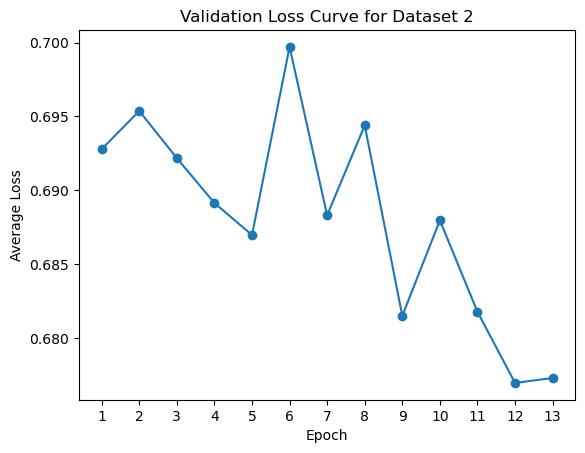

In [28]:
# plotting the Avg_Loss v/s Epoch on Validate data for Dataset 2
plt.plot(range(1, len(val_epoch_loss2 )+1), val_epoch_loss2 , marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Validation Loss Curve for Dataset 2")
plt.xticks(range(1, len(val_epoch_loss2 )+1))
plt.show()

In [30]:
# Validate and test performance
y2_val_pred = predict_lr(X_val2, w2, b2, threshold = 0.5)
val_accuracy2, val_precision2, val_recall2, val_f1_2 = evaluate(Y_val2, y2_val_pred)
print(f"Validate Accuracy for dataset1: {val_accuracy2*100:.2f}%")
print(f"Validate Precision for dataset1: {val_precision2*100:.2f}%")
print(f"Validate Recall for dataset1: {val_recall2*100:.2f}%")
print(f"Validate F1-score for dataset1: {val_f1_2*100:.2f}%")

    
y2_test_pred = predict_lr(X_test2, w2, b2, threshold = 0.5)
test_accuracy2, test_precision2, test_recall2, test_f1_2 = evaluate(Y_test2, y2_test_pred)
print(f"Test Accuracy for dataset1: {test_accuracy2*100:.2f}%")
print(f"Test Precision for dataset1: {test_precision2*100:.2f}%")
print(f"Test Recall for dataset1: {test_recall2*100:.2f}%")
print(f"Test F1-score for dataset1: {test_f1_2*100:.2f}%")

Validate Accuracy for dataset1: 48.00%
Validate Precision for dataset1: 48.48%
Validate Recall for dataset1: 42.11%
Validate F1-score for dataset1: 45.07%
Test Accuracy for dataset1: 40.00%
Test Precision for dataset1: 37.50%
Test Recall for dataset1: 32.43%
Test F1-score for dataset1: 34.78%


## Task 3: Implement and test a shallow Neural Network

In [17]:
def sigmoid_derivative(a):
    return a * (1 - a)

In [35]:
def initialize_network(n_inputs, n_hidden):
    np.random.seed(42)
    params = {}
    params['W1'] = np.random.randn(n_hidden, n_inputs) * 0.01
    params['b1'] = np.zeros((n_hidden, 1))
    params['W2'] = np.random.randn(1, n_hidden) * 0.01
    params['b2'] = np.zeros((1, 1))
    return params

In [36]:
def forward(x, params):
    z1 = np.dot(params['W1'], x) + params['b1']
    a1 = sigmoid(z1)
    z2 = np.dot(params['W2'], a1) + params['b2']
    a2 = sigmoid(z2)
    cache = {'x': x, 'z1': z1, 'a1': a1, 'z2': z2, 'a2': a2}
    return a2, cache

In [37]:
def backward(y, params, cache, learning_rate):
    x = cache['x']
    a1 = cache['a1']
    a2 = cache['a2']

    dz2 = a2 - y
    dW2 = np.dot(dz2, a1.T)
    db2 = dz2

    dz1 = np.dot(params['W2'].T, dz2) * sigmoid_derivative(a1)
    dW1 = np.dot(dz1, x.T)
    db1 = dz1

    # Update
    params['W2'] -= learning_rate * dW2
    params['b2'] -= learning_rate * db2
    params['W1'] -= learning_rate * dW1
    params['b1'] -= learning_rate * db1

    return params

In [38]:
def train_network(X, Y, n_hidden=2, learning_rate=0.001, epochs=1000, tolerance=1e-6):
    n_inputs = X.shape[0]
    params = initialize_network(n_inputs, n_hidden)
    m = X.shape[1]
    losses = []

    prev_loss = float('inf')
    converged_epoch = None

    for epoch in range(epochs):
        epoch_loss = 0

        for i in range(m):
            x = X[:, i:i+1]
            y = Y[:, i:i+1]

            a2, cache = forward(x, params)
            params = backward(y, params, cache, learning_rate)

            epsilon = 1e-8
            a2_clipped = np.clip(a2, epsilon, 1 - epsilon)
            loss_value = - (y * np.log(a2_clipped) + (1 - y) * np.log(1 - a2_clipped))
            epoch_loss += loss_value.item()

        loss_avg = epoch_loss / m
        losses.append(loss_avg)

        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1}, Loss: {loss_avg:.6f}")

        # Convergence Check
        if abs(prev_loss - loss_avg) < tolerance:
            converged_epoch = epoch + 1
            print(f"\nConverged at epoch {converged_epoch} with Loss: {loss_avg:.6f}")
            break

        prev_loss = loss_avg

    return params, losses, converged_epoch


In [39]:
def predict(X, params):
    m = X.shape[1]
    predictions = np.zeros((1, m))
    for i in range(m):
        x = X[:, i:i+1]
        a2, _ = forward(x, params)
        predictions[0, i] = 1 if a2 > 0.5 else 0
    return predictions

In [40]:


X_blobs_train = X_train1.T  # shape: (n_features, n_samples)
Y_blobs_train = Y_train1.reshape(1,-1)
X_blobs_test = X_test1.T 
Y_blobs_test = Y_test1.reshape(1,-1)
X_blobs_val = X_val1.T 
Y_blobs_val = Y_val1.reshape(1,-1)


NameError: name 'X_train1' is not defined

Running for 4 hidden nodes
Epoch 100, Loss: 0.112878
Epoch 200, Loss: 0.036908
Epoch 300, Loss: 0.024233
Epoch 400, Loss: 0.019151
Epoch 500, Loss: 0.016402
Epoch 600, Loss: 0.014670
Epoch 700, Loss: 0.013474
Epoch 800, Loss: 0.012596
Epoch 900, Loss: 0.011922
Epoch 1000, Loss: 0.011389
Epoch 1100, Loss: 0.010956
Epoch 1200, Loss: 0.010596
Epoch 1300, Loss: 0.010294
Epoch 1400, Loss: 0.010035
Epoch 1500, Loss: 0.009811
Epoch 1600, Loss: 0.009616
Epoch 1700, Loss: 0.009443
Epoch 1800, Loss: 0.009290
Epoch 1900, Loss: 0.009154
Epoch 2000, Loss: 0.009030
Epoch 2100, Loss: 0.008919

Converged at epoch 2164 with Loss: 0.008853
Test Accuracy for 4 hidden nodes: 1.00%
Test Precision for 4 hidden nodes: 1.00%
Test Recall for 4 hidden nodes: 1.00%
Test F1-score for 4 hidden nodes: 1.00%
Validate Accuracy for 4 hidden nodes: 0.99%
Validate Precision for 4 hidden nodes: 0.98%
Validate Recall for 4 hidden nodes: 1.00%
Validate F1-score for 4 hidden nodes: 0.99%


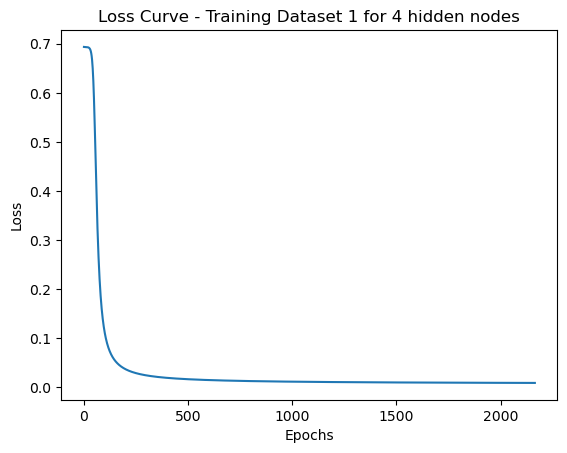

Running for 10 hidden nodes
Epoch 100, Loss: 0.062486
Epoch 200, Loss: 0.025011
Epoch 300, Loss: 0.017868
Epoch 400, Loss: 0.014890
Epoch 500, Loss: 0.013245
Epoch 600, Loss: 0.012193
Epoch 700, Loss: 0.011457
Epoch 800, Loss: 0.010909
Epoch 900, Loss: 0.010484
Epoch 1000, Loss: 0.010143
Epoch 1100, Loss: 0.009863
Epoch 1200, Loss: 0.009628
Epoch 1300, Loss: 0.009428
Epoch 1400, Loss: 0.009255
Epoch 1500, Loss: 0.009104
Epoch 1600, Loss: 0.008970
Epoch 1700, Loss: 0.008852
Epoch 1800, Loss: 0.008745

Converged at epoch 1810 with Loss: 0.008735
Test Accuracy for 10 hidden nodes: 1.00%
Test Precision for 10 hidden nodes: 1.00%
Test Recall for 10 hidden nodes: 1.00%
Test F1-score for 10 hidden nodes: 1.00%
Validate Accuracy for 10 hidden nodes: 0.99%
Validate Precision for 10 hidden nodes: 0.98%
Validate Recall for 10 hidden nodes: 1.00%
Validate F1-score for 10 hidden nodes: 0.99%


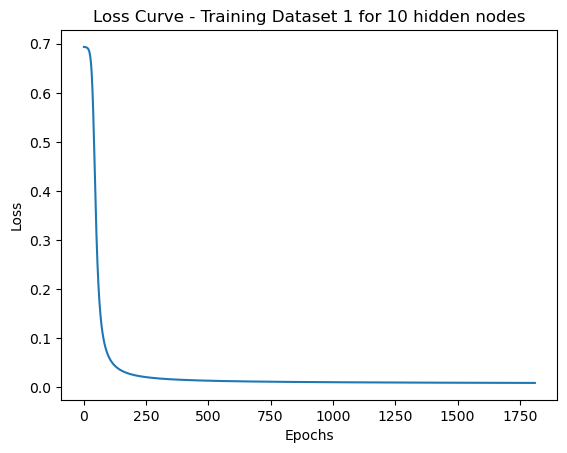

Running for 17 hidden nodes
Epoch 100, Loss: 0.056117
Epoch 200, Loss: 0.023139
Epoch 300, Loss: 0.016868
Epoch 400, Loss: 0.014238
Epoch 500, Loss: 0.012778
Epoch 600, Loss: 0.011839
Epoch 700, Loss: 0.011180
Epoch 800, Loss: 0.010688
Epoch 900, Loss: 0.010305
Epoch 1000, Loss: 0.009996
Epoch 1100, Loss: 0.009742
Epoch 1200, Loss: 0.009528
Epoch 1300, Loss: 0.009345
Epoch 1400, Loss: 0.009186
Epoch 1500, Loss: 0.009047
Epoch 1600, Loss: 0.008924
Epoch 1700, Loss: 0.008814

Converged at epoch 1740 with Loss: 0.008773
Test Accuracy for 17 hidden nodes: 1.00%
Test Precision for 17 hidden nodes: 1.00%
Test Recall for 17 hidden nodes: 1.00%
Test F1-score for 17 hidden nodes: 1.00%
Validate Accuracy for 17 hidden nodes: 0.99%
Validate Precision for 17 hidden nodes: 0.98%
Validate Recall for 17 hidden nodes: 1.00%
Validate F1-score for 17 hidden nodes: 0.99%


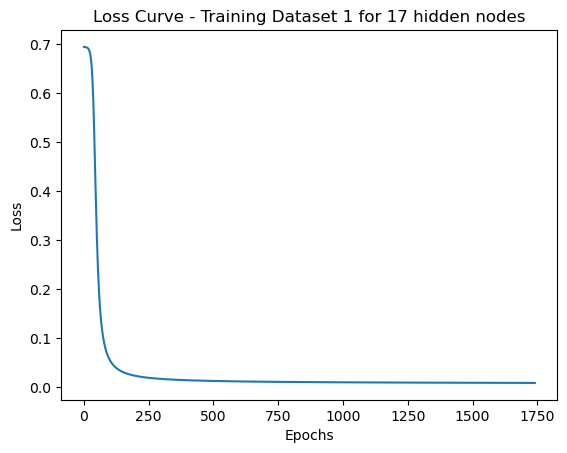

Running for 26 hidden nodes
Epoch 100, Loss: 0.049844
Epoch 200, Loss: 0.021636
Epoch 300, Loss: 0.016132
Epoch 400, Loss: 0.013783
Epoch 500, Loss: 0.012464
Epoch 600, Loss: 0.011609
Epoch 700, Loss: 0.011004
Epoch 800, Loss: 0.010551
Epoch 900, Loss: 0.010197
Epoch 1000, Loss: 0.009911
Epoch 1100, Loss: 0.009674
Epoch 1200, Loss: 0.009474
Epoch 1300, Loss: 0.009303
Epoch 1400, Loss: 0.009154
Epoch 1500, Loss: 0.009023
Epoch 1600, Loss: 0.008907

Converged at epoch 1687 with Loss: 0.008816
Test Accuracy for 26 hidden nodes: 1.00%
Test Precision for 26 hidden nodes: 1.00%
Test Recall for 26 hidden nodes: 1.00%
Test F1-score for 26 hidden nodes: 1.00%
Validate Accuracy for 26 hidden nodes: 0.99%
Validate Precision for 26 hidden nodes: 0.98%
Validate Recall for 26 hidden nodes: 1.00%
Validate F1-score for 26 hidden nodes: 0.99%


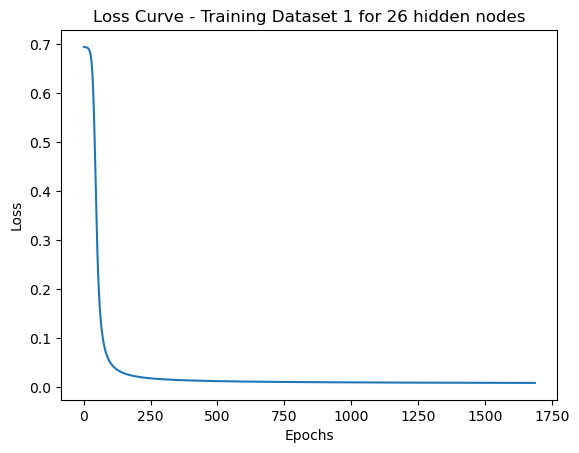

In [38]:
for n_hidden in [4,10,17,26]:
    print(f"Running for {n_hidden} hidden nodes")
    params_blobs_train, losses_blobs_train, converged_epoch_train = train_network(X_blobs_train, Y_blobs_train, n_hidden=n_hidden, learning_rate=0.001, epochs=50000)
    y_test_pred1 = predict(X_blobs_test, params_blobs_train)
    SNN_test_accuracy1, SNN_test_precision1, SNN_test_recall1, SNN_test_f1_1 = evaluate(Y_blobs_test, y_test_pred1)
    print(f"Test Accuracy for {n_hidden} hidden nodes: {SNN_test_accuracy1:.2f}%")
    print(f"Test Precision for {n_hidden} hidden nodes: {SNN_test_precision1:.2f}%")
    print(f"Test Recall for {n_hidden} hidden nodes: {SNN_test_recall1:.2f}%")
    print(f"Test F1-score for {n_hidden} hidden nodes: {SNN_test_f1_1:.2f}%")
    

    y_val_pred1 = predict(X_blobs_val, params_blobs_train)
    SNN_val_accuracy1, SNN_val_precision1, SNN_val_recall1, SNN_val_f1_1 = evaluate(Y_blobs_val, y_val_pred1)
    print(f"Validate Accuracy for {n_hidden} hidden nodes: {SNN_val_accuracy1:.2f}%")
    print(f"Validate Precision for {n_hidden} hidden nodes: {SNN_val_precision1:.2f}%")
    print(f"Validate Recall for {n_hidden} hidden nodes: {SNN_val_recall1:.2f}%")
    print(f"Validate F1-score for {n_hidden} hidden nodes: {SNN_val_f1_1:.2f}%")

    plt.plot(range(1, len(losses_blobs_train) + 1), losses_blobs_train)
    plt.title(f"Loss Curve - Training Dataset 1 for {n_hidden} hidden nodes")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()


Running for 4 hidden nodes
Epoch 100, Loss: 0.692338
Epoch 200, Loss: 0.636629
Epoch 300, Loss: 0.313057
Epoch 400, Loss: 0.144274
Epoch 500, Loss: 0.085657
Epoch 600, Loss: 0.059212
Epoch 700, Loss: 0.044702
Epoch 800, Loss: 0.035678
Epoch 900, Loss: 0.029572
Epoch 1000, Loss: 0.025188
Epoch 1100, Loss: 0.021897
Epoch 1200, Loss: 0.019341
Epoch 1300, Loss: 0.017301
Epoch 1400, Loss: 0.015639
Epoch 1500, Loss: 0.014258
Epoch 1600, Loss: 0.013095
Epoch 1700, Loss: 0.012102
Epoch 1800, Loss: 0.011244
Epoch 1900, Loss: 0.010497
Epoch 2000, Loss: 0.009840
Epoch 2100, Loss: 0.009258
Epoch 2200, Loss: 0.008739
Epoch 2300, Loss: 0.008274
Epoch 2400, Loss: 0.007854
Epoch 2500, Loss: 0.007474
Epoch 2600, Loss: 0.007128
Epoch 2700, Loss: 0.006811
Epoch 2800, Loss: 0.006521
Epoch 2900, Loss: 0.006254
Epoch 3000, Loss: 0.006008
Epoch 3100, Loss: 0.005779
Epoch 3200, Loss: 0.005567
Epoch 3300, Loss: 0.005370
Epoch 3400, Loss: 0.005185
Epoch 3500, Loss: 0.005013
Epoch 3600, Loss: 0.004851
Epoch 3700

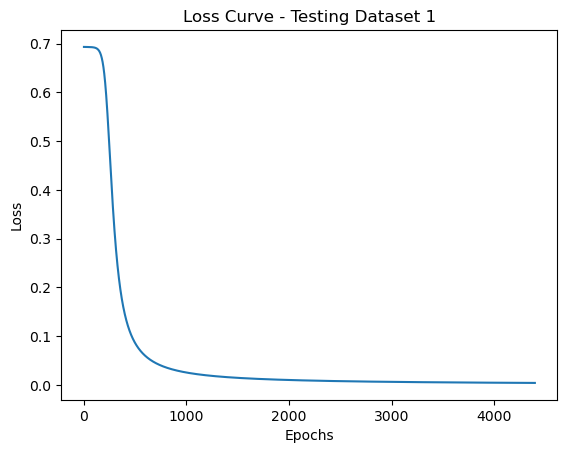

Epoch 100, Loss: 0.692471
Epoch 200, Loss: 0.641864
Epoch 300, Loss: 0.337688
Epoch 400, Loss: 0.169048
Epoch 500, Loss: 0.107356
Epoch 600, Loss: 0.078588
Epoch 700, Loss: 0.062449
Epoch 800, Loss: 0.052249
Epoch 900, Loss: 0.045261
Epoch 1000, Loss: 0.040188
Epoch 1100, Loss: 0.036341
Epoch 1200, Loss: 0.033323
Epoch 1300, Loss: 0.030890
Epoch 1400, Loss: 0.028885
Epoch 1500, Loss: 0.027200
Epoch 1600, Loss: 0.025762
Epoch 1700, Loss: 0.024517
Epoch 1800, Loss: 0.023428
Epoch 1900, Loss: 0.022463
Epoch 2000, Loss: 0.021602
Epoch 2100, Loss: 0.020827
Epoch 2200, Loss: 0.020124
Epoch 2300, Loss: 0.019482
Epoch 2400, Loss: 0.018893
Epoch 2500, Loss: 0.018350
Epoch 2600, Loss: 0.017846
Epoch 2700, Loss: 0.017376
Epoch 2800, Loss: 0.016938
Epoch 2900, Loss: 0.016526
Epoch 3000, Loss: 0.016139
Epoch 3100, Loss: 0.015773
Epoch 3200, Loss: 0.015427
Epoch 3300, Loss: 0.015099
Epoch 3400, Loss: 0.014787
Epoch 3500, Loss: 0.014490
Epoch 3600, Loss: 0.014206
Epoch 3700, Loss: 0.013934
Epoch 3800

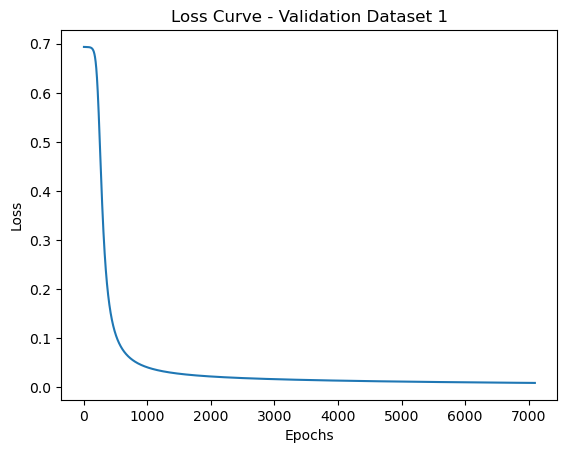

Running for 10 hidden nodes
Epoch 100, Loss: 0.684262
Epoch 200, Loss: 0.444090
Epoch 300, Loss: 0.149170
Epoch 400, Loss: 0.072841
Epoch 500, Loss: 0.045827
Epoch 600, Loss: 0.032812
Epoch 700, Loss: 0.025321
Epoch 800, Loss: 0.020505
Epoch 900, Loss: 0.017167
Epoch 1000, Loss: 0.014728
Epoch 1100, Loss: 0.012871
Epoch 1200, Loss: 0.011413
Epoch 1300, Loss: 0.010240
Epoch 1400, Loss: 0.009277
Epoch 1500, Loss: 0.008473
Epoch 1600, Loss: 0.007791
Epoch 1700, Loss: 0.007207
Epoch 1800, Loss: 0.006701
Epoch 1900, Loss: 0.006258
Epoch 2000, Loss: 0.005868
Epoch 2100, Loss: 0.005522
Epoch 2200, Loss: 0.005212
Epoch 2300, Loss: 0.004934
Epoch 2400, Loss: 0.004683
Epoch 2500, Loss: 0.004456
Epoch 2600, Loss: 0.004248
Epoch 2700, Loss: 0.004058
Epoch 2800, Loss: 0.003884
Epoch 2900, Loss: 0.003723
Epoch 3000, Loss: 0.003575
Epoch 3100, Loss: 0.003437
Epoch 3200, Loss: 0.003309
Epoch 3300, Loss: 0.003190
Epoch 3400, Loss: 0.003079
Epoch 3500, Loss: 0.002975

Converged at epoch 3511 with Loss: 

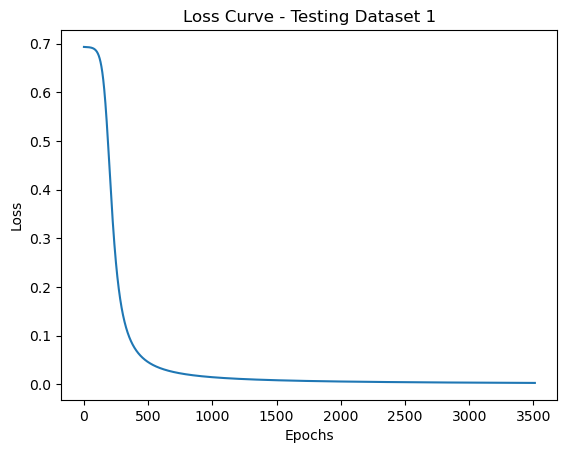

Epoch 100, Loss: 0.683574
Epoch 200, Loss: 0.443175
Epoch 300, Loss: 0.170464
Epoch 400, Loss: 0.095005
Epoch 500, Loss: 0.066212
Epoch 600, Loss: 0.051613
Epoch 700, Loss: 0.042900
Epoch 800, Loss: 0.037143
Epoch 900, Loss: 0.033067
Epoch 1000, Loss: 0.030032
Epoch 1100, Loss: 0.027683
Epoch 1200, Loss: 0.025811
Epoch 1300, Loss: 0.024280
Epoch 1400, Loss: 0.023003
Epoch 1500, Loss: 0.021918
Epoch 1600, Loss: 0.020984
Epoch 1700, Loss: 0.020168
Epoch 1800, Loss: 0.019447
Epoch 1900, Loss: 0.018805
Epoch 2000, Loss: 0.018227
Epoch 2100, Loss: 0.017704
Epoch 2200, Loss: 0.017226
Epoch 2300, Loss: 0.016786
Epoch 2400, Loss: 0.016380
Epoch 2500, Loss: 0.016004
Epoch 2600, Loss: 0.015652
Epoch 2700, Loss: 0.015323
Epoch 2800, Loss: 0.015013
Epoch 2900, Loss: 0.014721
Epoch 3000, Loss: 0.014444
Epoch 3100, Loss: 0.014182
Epoch 3200, Loss: 0.013932
Epoch 3300, Loss: 0.013694
Epoch 3400, Loss: 0.013466
Epoch 3500, Loss: 0.013248
Epoch 3600, Loss: 0.013038
Epoch 3700, Loss: 0.012837
Epoch 3800

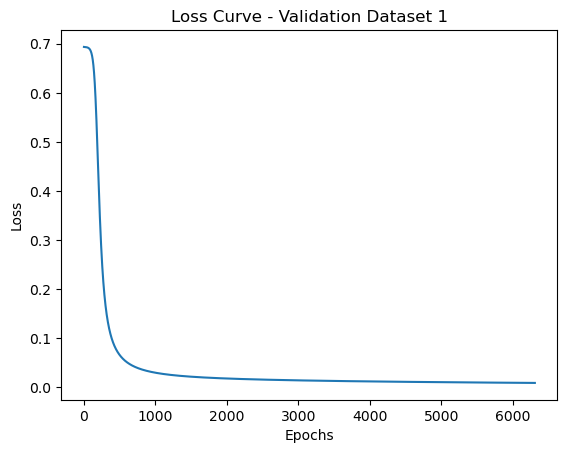

Running for 17 hidden nodes
Epoch 100, Loss: 0.685042
Epoch 200, Loss: 0.439248
Epoch 300, Loss: 0.135533
Epoch 400, Loss: 0.064832
Epoch 500, Loss: 0.040685
Epoch 600, Loss: 0.029163
Epoch 700, Loss: 0.022549
Epoch 800, Loss: 0.018296
Epoch 900, Loss: 0.015346
Epoch 1000, Loss: 0.013187
Epoch 1100, Loss: 0.011541
Epoch 1200, Loss: 0.010248
Epoch 1300, Loss: 0.009205
Epoch 1400, Loss: 0.008348
Epoch 1500, Loss: 0.007631
Epoch 1600, Loss: 0.007023
Epoch 1700, Loss: 0.006501
Epoch 1800, Loss: 0.006049
Epoch 1900, Loss: 0.005653
Epoch 2000, Loss: 0.005303
Epoch 2100, Loss: 0.004993
Epoch 2200, Loss: 0.004715
Epoch 2300, Loss: 0.004466
Epoch 2400, Loss: 0.004240
Epoch 2500, Loss: 0.004035
Epoch 2600, Loss: 0.003848
Epoch 2700, Loss: 0.003677
Epoch 2800, Loss: 0.003520
Epoch 2900, Loss: 0.003375
Epoch 3000, Loss: 0.003242
Epoch 3100, Loss: 0.003117
Epoch 3200, Loss: 0.003002
Epoch 3300, Loss: 0.002895

Converged at epoch 3357 with Loss: 0.002837


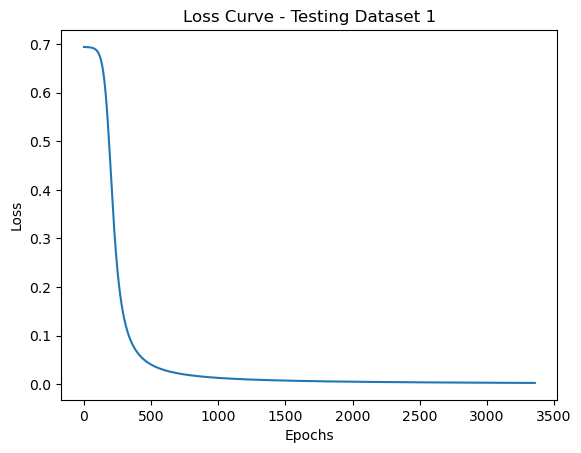

Epoch 100, Loss: 0.684919
Epoch 200, Loss: 0.441754
Epoch 300, Loss: 0.156827
Epoch 400, Loss: 0.086550
Epoch 500, Loss: 0.060746
Epoch 600, Loss: 0.047769
Epoch 700, Loss: 0.040025
Epoch 800, Loss: 0.034897
Epoch 900, Loss: 0.031256
Epoch 1000, Loss: 0.028538
Epoch 1100, Loss: 0.026429
Epoch 1200, Loss: 0.024743
Epoch 1300, Loss: 0.023363
Epoch 1400, Loss: 0.022208
Epoch 1500, Loss: 0.021226
Epoch 1600, Loss: 0.020378
Epoch 1700, Loss: 0.019637
Epoch 1800, Loss: 0.018981
Epoch 1900, Loss: 0.018396
Epoch 2000, Loss: 0.017868
Epoch 2100, Loss: 0.017389
Epoch 2200, Loss: 0.016951
Epoch 2300, Loss: 0.016548
Epoch 2400, Loss: 0.016175
Epoch 2500, Loss: 0.015828
Epoch 2600, Loss: 0.015503
Epoch 2700, Loss: 0.015199
Epoch 2800, Loss: 0.014912
Epoch 2900, Loss: 0.014642
Epoch 3000, Loss: 0.014385
Epoch 3100, Loss: 0.014141
Epoch 3200, Loss: 0.013908
Epoch 3300, Loss: 0.013686
Epoch 3400, Loss: 0.013473
Epoch 3500, Loss: 0.013268
Epoch 3600, Loss: 0.013072
Epoch 3700, Loss: 0.012883
Epoch 3800

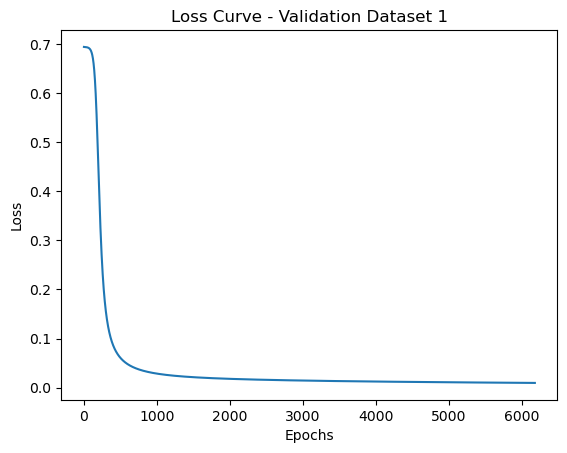

Running for 26 hidden nodes
Epoch 100, Loss: 0.685523
Epoch 200, Loss: 0.423173
Epoch 300, Loss: 0.117293
Epoch 400, Loss: 0.055916
Epoch 500, Loss: 0.035398
Epoch 600, Loss: 0.025587
Epoch 700, Loss: 0.019921
Epoch 800, Loss: 0.016256
Epoch 900, Loss: 0.013700
Epoch 1000, Loss: 0.011819
Epoch 1100, Loss: 0.010380
Epoch 1200, Loss: 0.009244
Epoch 1300, Loss: 0.008325
Epoch 1400, Loss: 0.007567
Epoch 1500, Loss: 0.006931
Epoch 1600, Loss: 0.006390
Epoch 1700, Loss: 0.005925
Epoch 1800, Loss: 0.005520
Epoch 1900, Loss: 0.005165
Epoch 2000, Loss: 0.004852
Epoch 2100, Loss: 0.004572
Epoch 2200, Loss: 0.004322
Epoch 2300, Loss: 0.004097
Epoch 2400, Loss: 0.003893
Epoch 2500, Loss: 0.003708
Epoch 2600, Loss: 0.003539
Epoch 2700, Loss: 0.003384
Epoch 2800, Loss: 0.003241
Epoch 2900, Loss: 0.003109
Epoch 3000, Loss: 0.002987
Epoch 3100, Loss: 0.002874
Epoch 3200, Loss: 0.002769

Converged at epoch 3223 with Loss: 0.002746


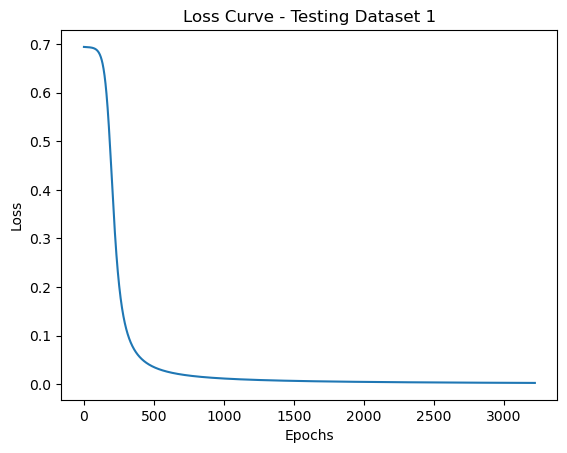

Epoch 100, Loss: 0.685773
Epoch 200, Loss: 0.431530
Epoch 300, Loss: 0.140914
Epoch 400, Loss: 0.078607
Epoch 500, Loss: 0.056110
Epoch 600, Loss: 0.044718
Epoch 700, Loss: 0.037855
Epoch 800, Loss: 0.033271
Epoch 900, Loss: 0.029993
Epoch 1000, Loss: 0.027530
Epoch 1100, Loss: 0.025610
Epoch 1200, Loss: 0.024069
Epoch 1300, Loss: 0.022802
Epoch 1400, Loss: 0.021739
Epoch 1500, Loss: 0.020832
Epoch 1600, Loss: 0.020048
Epoch 1700, Loss: 0.019360
Epoch 1800, Loss: 0.018750
Epoch 1900, Loss: 0.018205
Epoch 2000, Loss: 0.017713
Epoch 2100, Loss: 0.017265
Epoch 2200, Loss: 0.016854
Epoch 2300, Loss: 0.016476
Epoch 2400, Loss: 0.016126
Epoch 2500, Loss: 0.015799
Epoch 2600, Loss: 0.015493
Epoch 2700, Loss: 0.015206
Epoch 2800, Loss: 0.014935
Epoch 2900, Loss: 0.014678
Epoch 3000, Loss: 0.014435
Epoch 3100, Loss: 0.014203
Epoch 3200, Loss: 0.013981
Epoch 3300, Loss: 0.013769
Epoch 3400, Loss: 0.013566
Epoch 3500, Loss: 0.013370
Epoch 3600, Loss: 0.013182
Epoch 3700, Loss: 0.013001
Epoch 3800

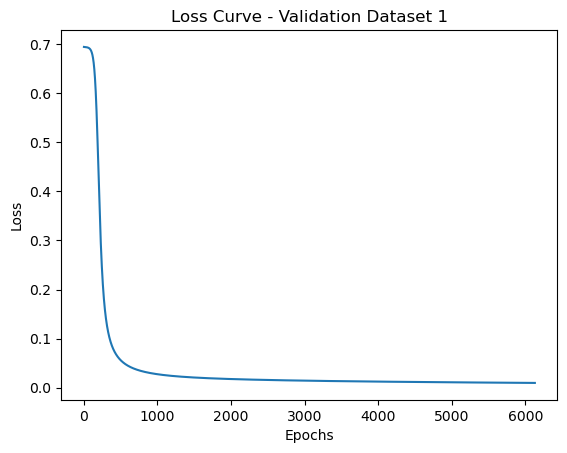

In [39]:
for n_hidden in [4,10,17,26]:
    print(f"Running for {n_hidden} hidden nodes")
    params_blobs_test, losses_blobs_test, converged_epoch_test = train_network(X_blobs_test, Y_blobs_test, n_hidden=n_hidden, learning_rate=0.001, epochs=50000)
    y_test_pred1 = predict(X_blobs_test, params_blobs_test)
    
    plt.plot(range(1, len(losses_blobs_test) + 1), losses_blobs_test)
    plt.title("Loss Curve - Testing Dataset 1")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()

    params_blobs_val, losses_blobs_val, converged_epoch_val = train_network(
    X_blobs_val, 
    Y_blobs_val, 
    n_hidden=n_hidden, 
    learning_rate=0.001, 
    epochs=50000
    )

    plt.plot(range(1, len(losses_blobs_val) + 1), losses_blobs_val)
    plt.title("Loss Curve - Validation Dataset 1")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()


### Implementing SNN on Dataset 2 (Non-linearly separable data)

In [40]:
X_circles_train = X_train2.T
Y_circles_train = Y_train2.reshape(1,-1)
X_circles_test = X_test2.T
Y_circles_test = Y_test2.reshape(1, -1)
X_circles_val = X_val2.T
Y_circles_val = Y_val2.reshape(1, -1)

Running for 4 hidden nodes

Converged at epoch 5 with Loss: 0.695515
Test Accuracy for 4 hidden nodes: 0.49%
Test Precision for 4 hidden nodes: 0.49%
Test Recall for 4 hidden nodes: 1.00%
Test F1-score for 4 hidden nodes: 0.66%
Validate Accuracy for 4 hidden nodes: 0.51%
Validate Precision for 4 hidden nodes: 0.51%
Validate Recall for 4 hidden nodes: 1.00%
Validate F1-score for 4 hidden nodes: 0.67%


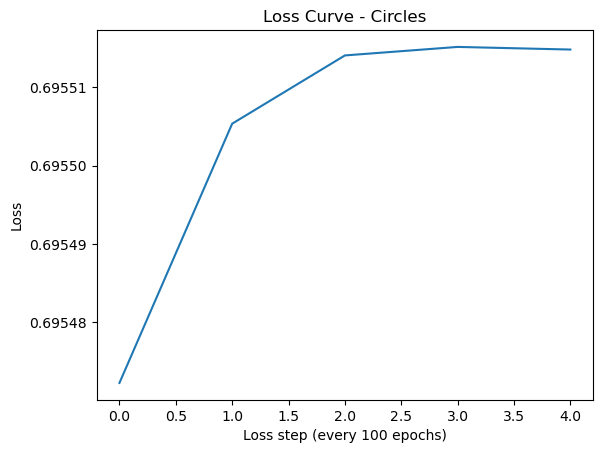

Running for 10 hidden nodes
Epoch 100, Loss: 0.696978
Epoch 200, Loss: 0.696643
Epoch 300, Loss: 0.695716
Epoch 400, Loss: 0.694946
Epoch 500, Loss: 0.683859
Epoch 600, Loss: 0.601622
Epoch 700, Loss: 0.506410
Epoch 800, Loss: 0.192136
Epoch 900, Loss: 0.116151
Epoch 1000, Loss: 0.085984
Epoch 1100, Loss: 0.068621
Epoch 1200, Loss: 0.057340
Epoch 1300, Loss: 0.049120
Epoch 1400, Loss: 0.042821
Epoch 1500, Loss: 0.037867
Epoch 1600, Loss: 0.033887
Epoch 1700, Loss: 0.030620
Epoch 1800, Loss: 0.027881
Epoch 1900, Loss: 0.025543
Epoch 2000, Loss: 0.023519
Epoch 2100, Loss: 0.021747
Epoch 2200, Loss: 0.020181
Epoch 2300, Loss: 0.018787
Epoch 2400, Loss: 0.017535
Epoch 2500, Loss: 0.016405
Epoch 2600, Loss: 0.015377
Epoch 2700, Loss: 0.014439
Epoch 2800, Loss: 0.013580
Epoch 2900, Loss: 0.012790
Epoch 3000, Loss: 0.012064
Epoch 3100, Loss: 0.011396
Epoch 3200, Loss: 0.010781
Epoch 3300, Loss: 0.010214
Epoch 3400, Loss: 0.009693
Epoch 3500, Loss: 0.009211
Epoch 3600, Loss: 0.008768
Epoch 370

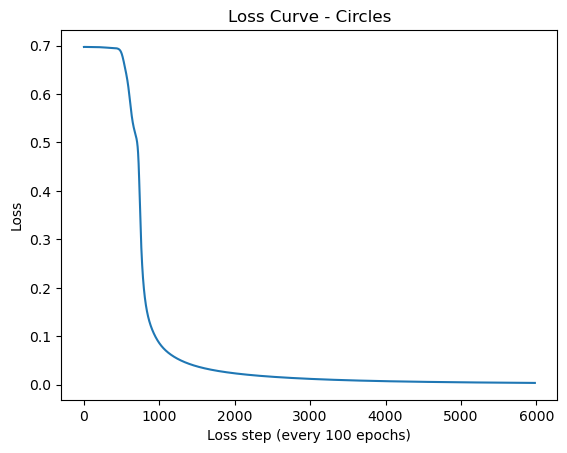

Running for 17 hidden nodes
Epoch 100, Loss: 0.698621
Epoch 200, Loss: 0.697905
Epoch 300, Loss: 0.696896
Epoch 400, Loss: 0.695831
Epoch 500, Loss: 0.669218
Epoch 600, Loss: 0.561744
Epoch 700, Loss: 0.488602
Epoch 800, Loss: 0.153255
Epoch 900, Loss: 0.080118
Epoch 1000, Loss: 0.056017
Epoch 1100, Loss: 0.044161
Epoch 1200, Loss: 0.036596
Epoch 1300, Loss: 0.030865
Epoch 1400, Loss: 0.026111
Epoch 1500, Loss: 0.022254
Epoch 1600, Loss: 0.019254
Epoch 1700, Loss: 0.016928
Epoch 1800, Loss: 0.015096
Epoch 1900, Loss: 0.013625
Epoch 2000, Loss: 0.012421
Epoch 2100, Loss: 0.011418
Epoch 2200, Loss: 0.010568
Epoch 2300, Loss: 0.009839
Epoch 2400, Loss: 0.009207
Epoch 2500, Loss: 0.008653
Epoch 2600, Loss: 0.008164
Epoch 2700, Loss: 0.007728
Epoch 2800, Loss: 0.007338
Epoch 2900, Loss: 0.006987
Epoch 3000, Loss: 0.006668
Epoch 3100, Loss: 0.006379
Epoch 3200, Loss: 0.006114
Epoch 3300, Loss: 0.005871
Epoch 3400, Loss: 0.005647
Epoch 3500, Loss: 0.005441
Epoch 3600, Loss: 0.005249
Epoch 370

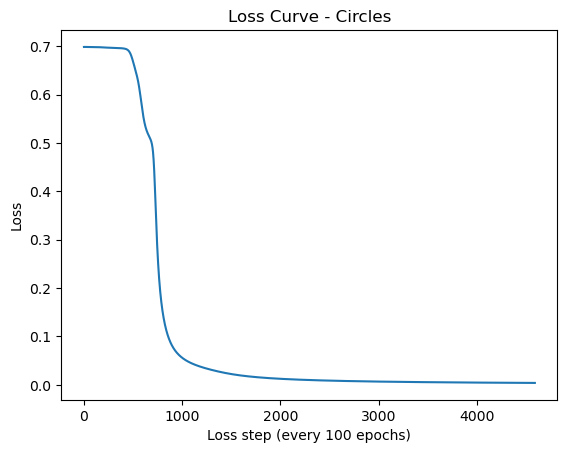

Running for 26 hidden nodes
Epoch 100, Loss: 0.700662
Epoch 200, Loss: 0.699922
Epoch 300, Loss: 0.698858
Epoch 400, Loss: 0.698408
Epoch 500, Loss: 0.696805
Epoch 600, Loss: 0.657241
Epoch 700, Loss: 0.543503
Epoch 800, Loss: 0.390272
Epoch 900, Loss: 0.129965
Epoch 1000, Loss: 0.083934
Epoch 1100, Loss: 0.065419
Epoch 1200, Loss: 0.054669
Epoch 1300, Loss: 0.047263
Epoch 1400, Loss: 0.041679
Epoch 1500, Loss: 0.037223
Epoch 1600, Loss: 0.033515
Epoch 1700, Loss: 0.030324
Epoch 1800, Loss: 0.027519
Epoch 1900, Loss: 0.025046
Epoch 2000, Loss: 0.022889
Epoch 2100, Loss: 0.021031
Epoch 2200, Loss: 0.019437
Epoch 2300, Loss: 0.018065
Epoch 2400, Loss: 0.016876
Epoch 2500, Loss: 0.015836
Epoch 2600, Loss: 0.014919
Epoch 2700, Loss: 0.014103
Epoch 2800, Loss: 0.013371
Epoch 2900, Loss: 0.012711
Epoch 3000, Loss: 0.012112
Epoch 3100, Loss: 0.011565
Epoch 3200, Loss: 0.011064
Epoch 3300, Loss: 0.010602
Epoch 3400, Loss: 0.010176
Epoch 3500, Loss: 0.009781
Epoch 3600, Loss: 0.009413
Epoch 370

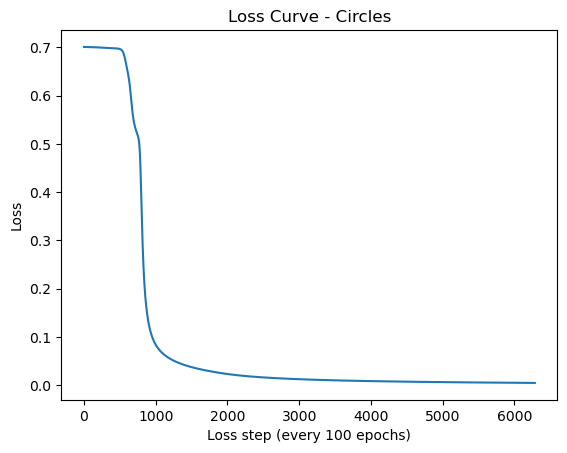

In [41]:
for n_hidden in [4,10,17,26]:
    print(f"Running for {n_hidden} hidden nodes")
    params_circles_train, losses_circles_train, converged_epoch_train = train_network(X_circles_train, Y_circles_train, n_hidden=n_hidden, learning_rate=0.01, epochs=20000)
    y_test_pred2 = predict(X_circles_test, params_circles_train)
    SNN_test_accuracy2, SNN_test_precision2, SNN_test_recall2, SNN_test_f1_2 = evaluate(Y_circles_test, y_test_pred2)
    print(f"Test Accuracy for {n_hidden} hidden nodes: {SNN_test_accuracy2:.2f}%")
    print(f"Test Precision for {n_hidden} hidden nodes: {SNN_test_precision2:.2f}%")
    print(f"Test Recall for {n_hidden} hidden nodes: {SNN_test_recall2:.2f}%")
    print(f"Test F1-score for {n_hidden} hidden nodes: {SNN_test_f1_2:.2f}%")

    y_val_pred2 = predict(X_circles_val, params_circles_train)
    SNN_val_accuracy2, SNN_val_precision2, SNN_val_recall2, SNN_val_f1_2 = evaluate(Y_circles_val, y_val_pred2)
    print(f"Validate Accuracy for {n_hidden} hidden nodes: {SNN_val_accuracy2:.2f}%")
    print(f"Validate Precision for {n_hidden} hidden nodes: {SNN_val_precision2:.2f}%")
    print(f"Validate Recall for {n_hidden} hidden nodes: {SNN_val_recall2:.2f}%")
    print(f"Validate F1-score for {n_hidden} hidden nodes: {SNN_val_f1_2:.2f}%")

    plt.plot(losses_circles_train)
    plt.title("Loss Curve - Circles")
    plt.xlabel("Loss step (every 100 epochs)")
    plt.ylabel("Loss")
    plt.show()

    

Running for 4 hidden nodes

Converged at epoch 22 with Loss: 0.693318


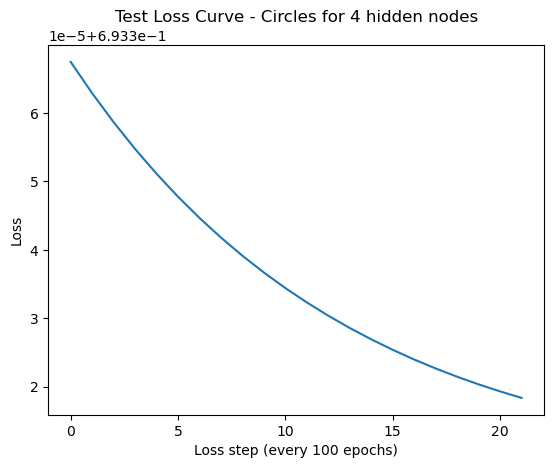


Converged at epoch 30 with Loss: 0.693314


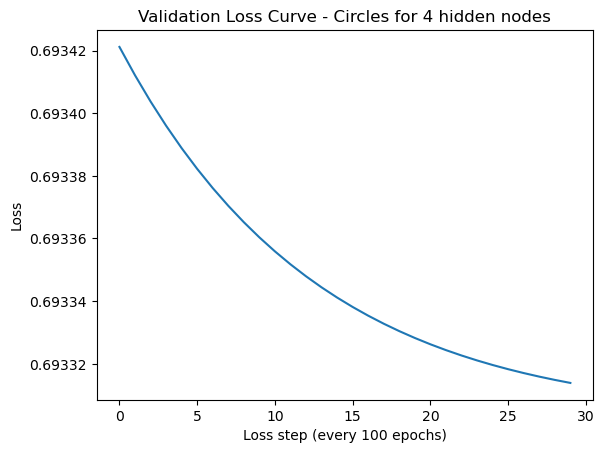

Running for 10 hidden nodes

Converged at epoch 12 with Loss: 0.693498


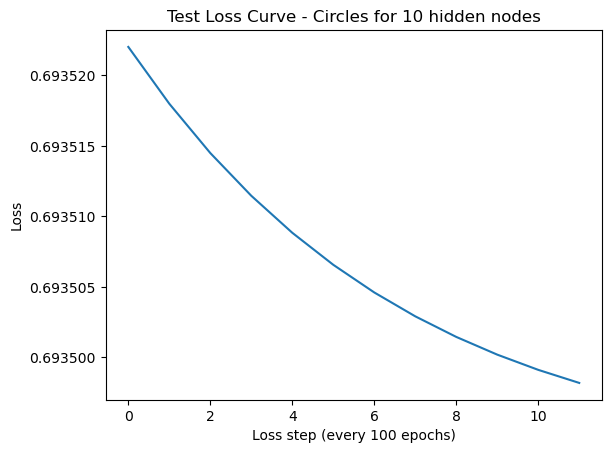


Converged at epoch 23 with Loss: 0.693497


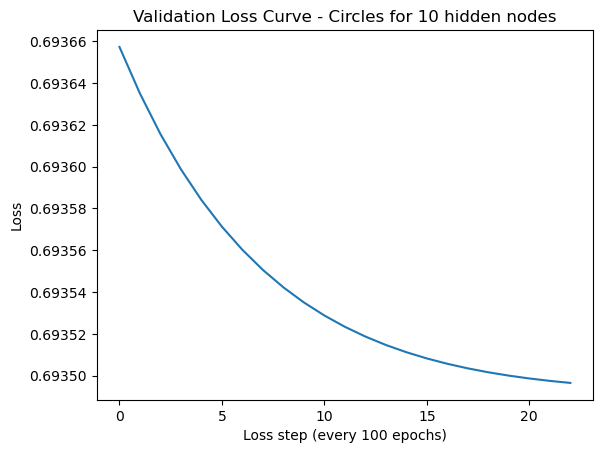

Running for 17 hidden nodes

Converged at epoch 2 with Loss: 0.693717


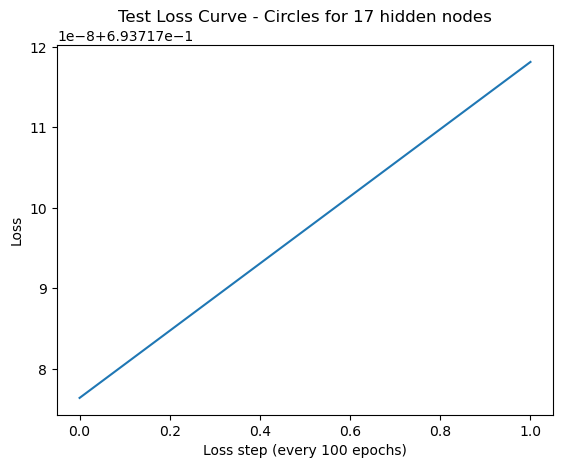


Converged at epoch 20 with Loss: 0.693716


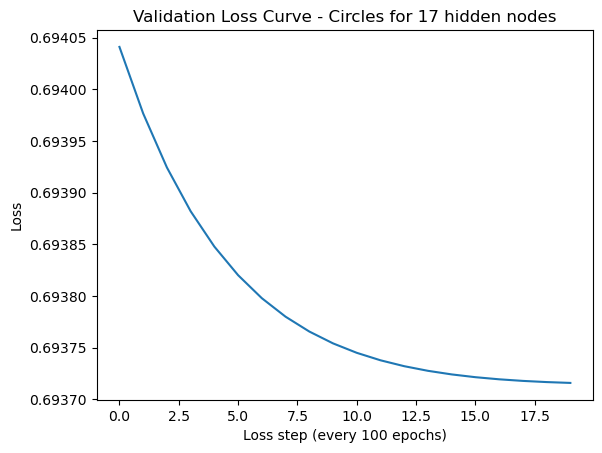

Running for 26 hidden nodes

Converged at epoch 14 with Loss: 0.693982


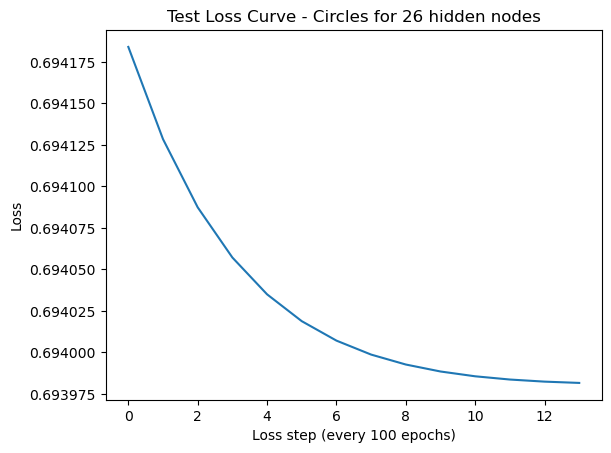


Converged at epoch 5 with Loss: 0.693970


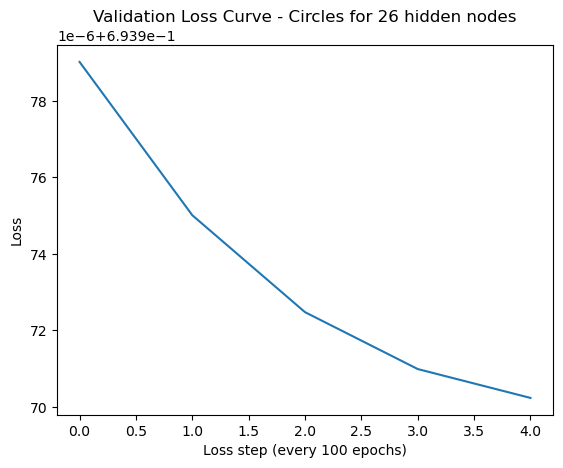

In [42]:
for n_hidden in [4,10,17,26]:
    print(f"Running for {n_hidden} hidden nodes")
    params_circles_test, losses_circles_test, converged_epoch_test = train_network(X_circles_test, Y_circles_test, n_hidden=n_hidden, learning_rate=0.001, epochs=20000)

    plt.plot(losses_circles_test)
    plt.title(f"Test Loss Curve - Circles for {n_hidden} hidden nodes")
    plt.xlabel("Loss step (every 100 epochs)")
    plt.ylabel("Loss")
    plt.show()

    params_circles_val, losses_circles_val, converged_epoch_val = train_network(X_circles_val, Y_circles_val, n_hidden=n_hidden, learning_rate=0.001, epochs=20000)   

    plt.plot(losses_circles_val)
    plt.title(f"Validation Loss Curve - Circles for {n_hidden} hidden nodes")
    plt.xlabel("Loss step (every 100 epochs)")
    plt.ylabel("Loss")
    plt.show()

## Task 4: Tackle a challenging task

In [18]:
data = np.load(r"C:\Users\anush\Downloads\emnist_letters_85800.npz")
x_data = data["x"]
y_data = data["y"]

In [19]:
# Do some data checks ...

# Check how many different classes we have: should be 26
n_classes =len(np.unique(y_data))
print(f"The number of unique classes is {n_classes} (should be 26).")

# check that images are scaled: min should be 0, max should be 1
img = x_data[0]
print(f"\nFor a single image, the min value is {img.min()} and the max is {img.max()} (should be 0.0 and 1.0).")

# Check the shape of the two classes
print(f"\nShape of x_data is {x_data.shape}, shape of y_data is {y_data.shape} (should have 85,800 cases and x should be 28x28).")

The number of unique classes is 26 (should be 26).

For a single image, the min value is 0.0 and the max is 1.0 (should be 0.0 and 1.0).

Shape of x_data is (85800, 28, 28, 1), shape of y_data is (85800,) (should have 85,800 cases and x should be 28x28).


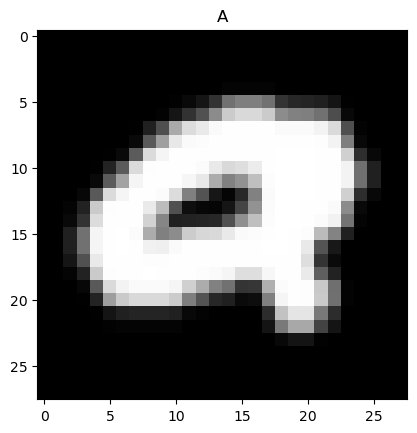

In [20]:
# Plot the first image

plt.imshow(x_data[0].squeeze(), cmap="gray")
plt.title(chr(int(y_data[0]) + 64))  
plt.show()

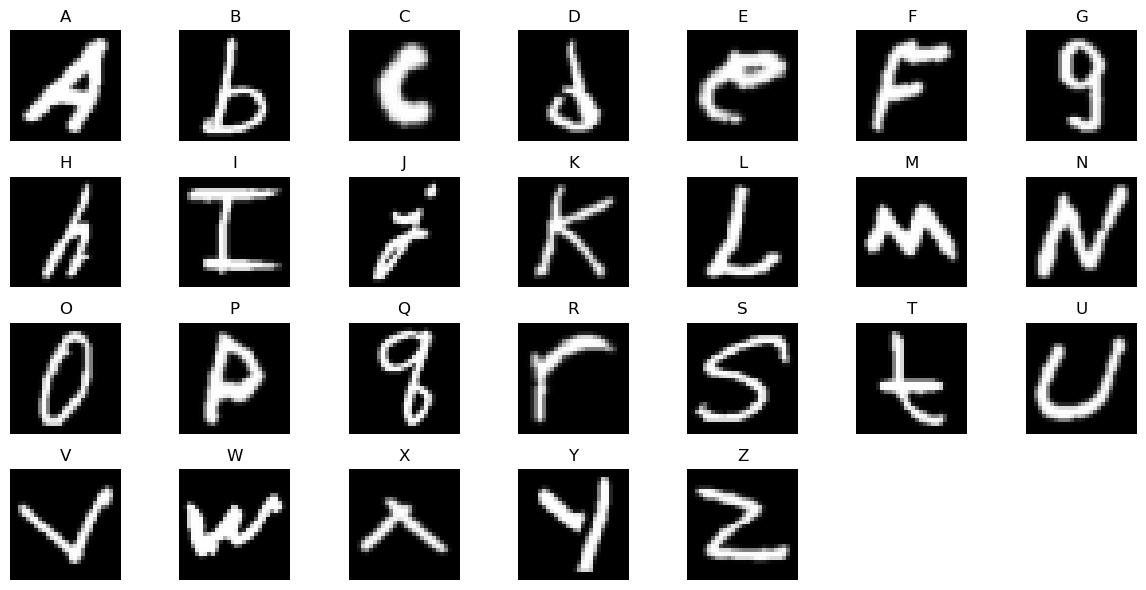

In [21]:
# Plot one item per class
n = 1000  # plot the n-th item, starting from 0

# Get unique labels
classes = np.unique(y_data)

plt.figure(figsize=(12, 6))

for i, cls in enumerate(classes):
    # Find first index of this class
    idx = np.where(y_data == cls)[0][n]
    
    plt.subplot(4, 7, i + 1)
    plt.imshow(x_data[idx].squeeze(), cmap="gray")
    plt.title(chr(int(cls) + 64))  # 1->A, 2->B, ...
    plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
# Extract just two classes from the dataset

# PUT YOUR OWN CLASS NUMBERS HERE: remember that A=1, z=26.
c1 = 1   # example
c2 = 18  # example

mask = (y_data == c1) | (y_data == c2)

x_binary = x_data[mask]
y_binary = y_data[mask]

# Now change labels to 0 and 1
y_binary = (y_binary == c2).astype(int)

In [23]:
# To help you examine your data, here is a graph to plot 48  images in a grid, starting from an index you specify.

def plot_grid(x, y, n):
    plt.figure(figsize=(12, 10))
    
    for i in range(48):
        idx = n + i
        
        plt.subplot(6, 8, i + 1)
        plt.imshow(x[idx].squeeze(), cmap="gray")
        plt.title(int(y[idx]))
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

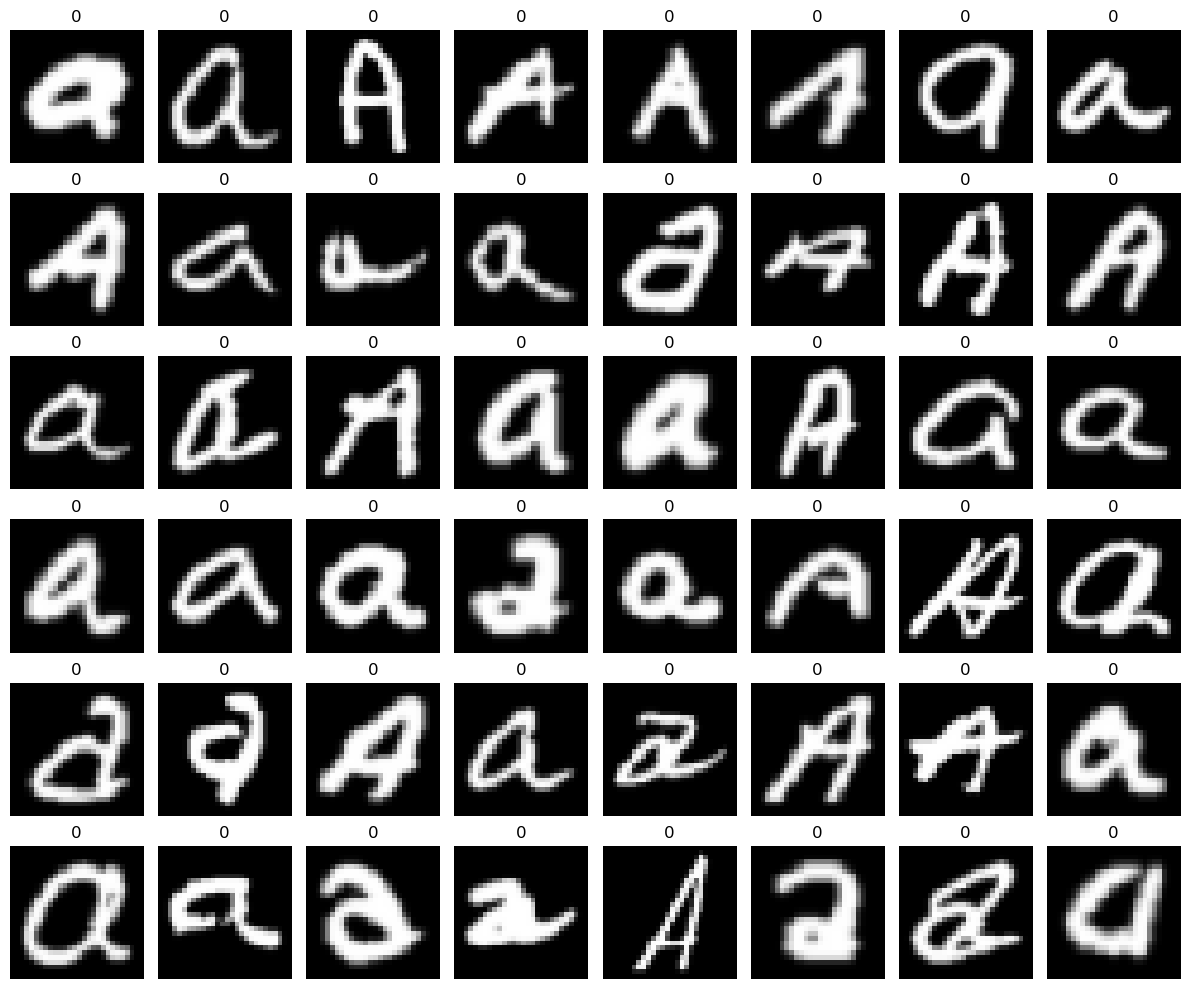

In [24]:
# Let's check images at the start - will all have label 0

plot_grid(x_binary, y_binary, n=0)

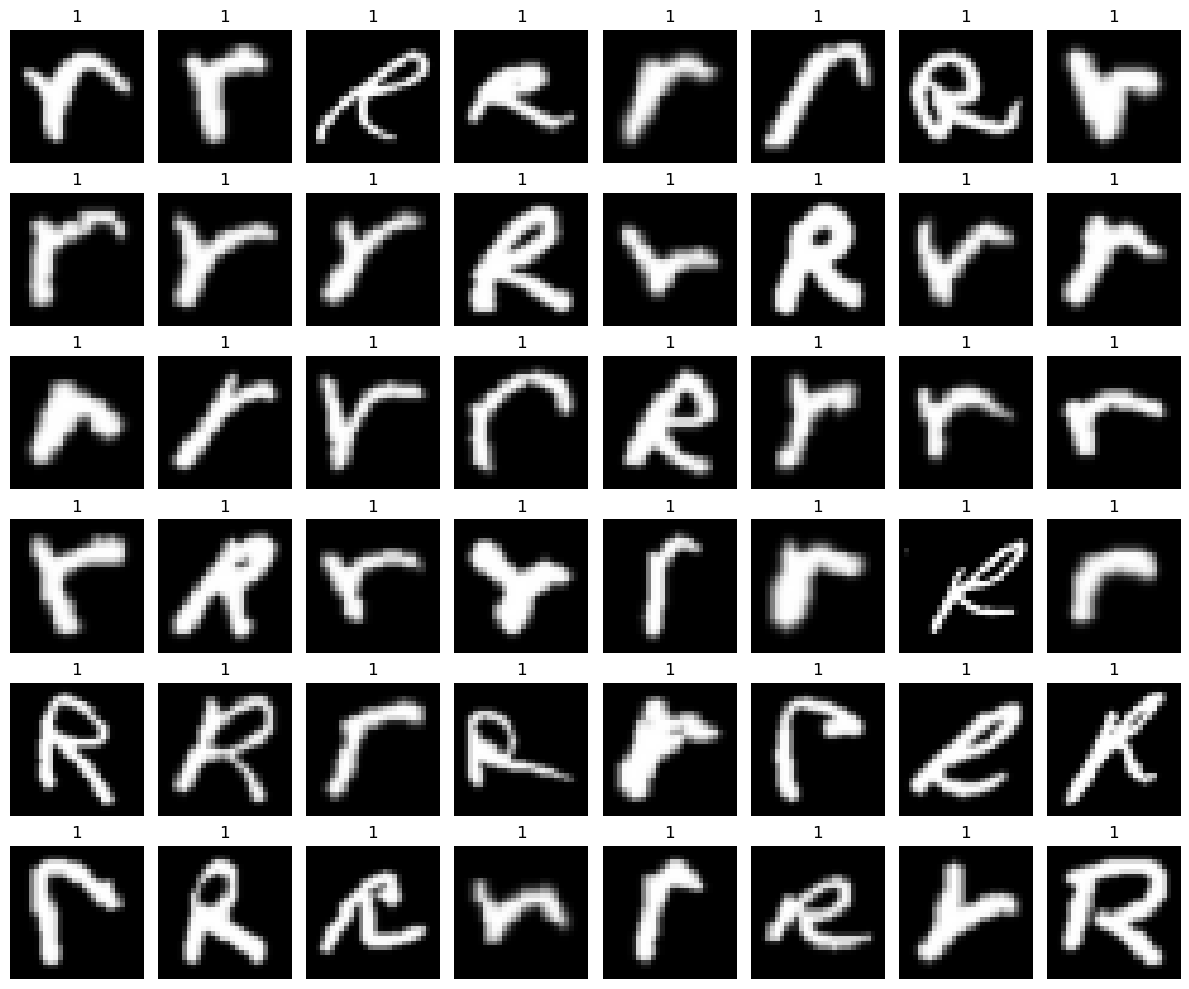

In [25]:
# Now check images after 3300 - will all have label 1

plot_grid(x_binary, y_binary, n=3300)

In [26]:
#Flattening image
x_binary = x_binary.reshape(x_binary.shape[0], -1).T  #(features x samples) format --> changing this format for feasible matrix multiplication
y_binary = y_binary.reshape(1, -1)                    #(1 x samples) format
y_binary_1d = y_binary.flatten()                      

In [27]:
#implementing train test val split
X_temp, X_test, Y_temp, Y_test = train_test_split(
    x_binary.T, y_binary_1d, test_size=0.2, random_state=42, stratify=y_binary_1d
)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_temp, Y_temp, test_size=0.25, random_state=42, stratify=Y_temp
) 


In [28]:
X_train, X_val, X_test = X_train.T, X_val.T, X_test.T   #getting back to original data format (samples x features)

In [29]:
Y_train = Y_train.reshape(1, -1)
Y_val   = Y_val.reshape(1, -1)
Y_test  = Y_test.reshape(1, -1)

In [30]:
print(f"X_train shape: {X_train.shape}, Y_train shape: {Y_train.shape}")

X_train shape: (784, 3960), Y_train shape: (1, 3960)


In [41]:
for n_hidden in [3, 4, 6]:
    print(f"Running for {n_hidden} hidden nodes")
    params_letters, losses_letters, convergence_epoch = train_network(
        X_train, Y_train, n_hidden=n_hidden, learning_rate=0.1, epochs=2000
    )
    
    plt.plot(np.arange(1, len(losses_letters)+1) * 100, losses_letters)
    plt.title("Train Loss Curve - Task 4")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()

    pred_train = predict(X_train, params_letters)
    pred_val = predict(X_val, params_letters)
    pred_test = predict(X_test, params_letters)

    SNN_train_accuracy, SNN_train_precision, SNN_train_recall, SNN_train_f1 = evaluate(Y_train, pred_train)
    SNN_test_accuracy, SNN_test_precision, SNN_test_recall, SNN_test_f1 = evaluate(Y_test, pred_test)
    SNN_val_accuracy, SNN_val_precision, SNN_val_recall, SNN_val_f1 = evaluate(Y_val, pred_val)

    print(f"Train Accuracy: {SNN_train_accuracy*100:.2f}%")
    print(f"Train Precision: {SNN_train_precision*100:.2f}%")
    print(f"Train Recall: {SNN_train_recall*100:.2f}%")
    print(f"Train F1-score: {SNN_train_f1*100:.2f}%")
    
    print(f"Test Accuracy: {SNN_test_accuracy*100:.2f}%")
    print(f"Test Precision: {SNN_test_precision*100:.2f}%")
    print(f"Test Recall: {SNN_test_recall*100:.2f}%")
    print(f"Test F1-score: {SNN_test_f1*100:.2f}%")
    
    print(f"Validate Accuracy: {SNN_val_accuracy*100:.2f}%")
    print(f"Validate Precision: {SNN_val_precision*100:.2f}%")
    print(f"Validate Recall: {SNN_val_recall*100:.2f}%")
    print(f"Validate F1-score: {SNN_val_f1*100:.2f}%")

Running for 3 hidden nodes


KeyboardInterrupt: 

## Task 5: Deep Learning Enhancements

In [47]:
def initialize_parameters(layer_dimensions):

    np.random.seed(42)
    parameters = {}

    for l in range(1, len(layer_dimensions)):
        scale = np.sqrt(1 / layer_dimensions[l-1])

        parameters[f"W{l}"] = np.random.randn(
            layer_dimensions[l], layer_dimensions[l-1]
        ) * scale

        parameters[f"b{l}"] = np.zeros((layer_dimensions[l], 1))

    return parameters

def forward_propagation(X, parameters, training=True):

    cache = {"A0": X}
    L = len(parameters)//2
   
    for l in range(1, L):

        output = parameters[f"W{l}"] @ cache[f"A{l-1}"] + parameters[f"b{l}"]
        activation = sigmoid(output)

        cache[f"Z{l}"] = output
        cache[f"A{l}"] = activation

    output_layer = parameters[f"W{L}"] @ cache[f"A{L-1}"] + parameters[f"b{L}"]
    activation_layer_output = sigmoid(output_layer)

    cache[f"output{L}"] = output_layer
    cache[f"activation{L}"] = activation_layer_output
   
    return activation_layer_output, cache

def compute_loss(activation_layer_output, Y, parameters, lambda_l2=0.01):

    m = Y.shape[1]
    epsilon = 1e-15
   
    activation_layer_output = np.clip(activation_layer_output, epsilon, 1-epsilon)

    cross_entropy = -np.mean(Y*np.log(activation_layer_output) + (1-Y)*np.log(1-activation_layer_output))

    # L2 term
    l2 = 0
    for l in range(1, len(parameters)//2 + 1):
        l2 += np.sum(np.square(parameters[f"W{l}"]))

    l2_term = (lambda_l2/(2*m)) * l2

    return cross_entropy + l2_term



In [48]:
def backward_propagation(parameters, cache, X, Y, lambda_l2=0.01):

    gradients = {}
    L = len(parameters)//2
    m = X.shape[1]

    activation_layer_output = cache[f"activation{L}"]
    dZ = activation_layer_output - Y

    for l in reversed(range(1, L+1)):

        gradients[f"dW{l}"] = (1/m)*(dZ @ cache[f"A{l-1}"].T) + (lambda_l2/m)*parameters[f"W{l}"]
        gradients[f"db{l}"] = (1/m)*np.sum(dZ, axis=1, keepdims=True)

        if l > 1:
            dA_prev = parameters[f"W{l}"].T @ dZ
            A_prev = cache[f"A{l-1}"]
            dZ = dA_prev * sigmoid_derivative(A_prev)

    return gradients

In [49]:
def update_parameters(parameters, gradients, lr):

    for l in range(1, len(parameters)//2 + 1):
        parameters[f"W{l}"] -= lr * gradients[f"dW{l}"]
        parameters[f"b{l}"] -= lr * gradients[f"db{l}"]

    return parameters

In [50]:
def train_deep_network(X, Y, X_val, Y_val,
                       layers,
                       lr=0.01,
                       epochs=2000,
                       lambda_l2=0.01,
                       tolerance=1e-8,
                       patience=5000):

    parameters = initialize_parameters(layers)
    losses = []
    val_losses = []

    best_val_loss = float('inf')
    patience_counter = 0

    for i in range(epochs):

        activation_layer_output, cache = forward_propagation(X, parameters)
        loss = compute_loss(activation_layer_output, Y, parameters, lambda_l2)
        losses.append(loss)

        activation_val, _ = forward_propagation(X_val, parameters)
        val_loss = compute_loss(activation_val, Y_val, parameters, lambda_l2)
        val_losses.append(val_loss)

        gradients = backward_propagation(parameters, cache, X, Y, lambda_l2)
        parameters = update_parameters(parameters, gradients, lr)

        if val_loss < best_val_loss - tolerance:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter > patience:
            print(f"Early stopping at epoch {i}")
            break

        if i % 200 == 0:
            print(f"Epoch {i} | Train Loss: {loss:.4f} | Val Loss: {val_loss:.4f}")

    return parameters, losses, val_losses


In [64]:
def predict_deep(X, params):
    # Forward pass
    activation_layer_output, _ = forward_propagation(X, params)
    # Convert probabilities to 0/1
    predictions = (activation_layer_output > 0.5).astype(int)
    return predictions



In [65]:
def accuracy(Y, pred):
    return np.mean(Y == pred) * 100


Training network with layers: [784, 4, 1]
Epoch 0 | Train Loss: 0.6917 | Val Loss: 0.6913
Epoch 200 | Train Loss: 0.2433 | Val Loss: 0.2591
Epoch 400 | Train Loss: 0.1705 | Val Loss: 0.1913
Epoch 600 | Train Loss: 0.1478 | Val Loss: 0.1731
Epoch 800 | Train Loss: 0.1369 | Val Loss: 0.1663


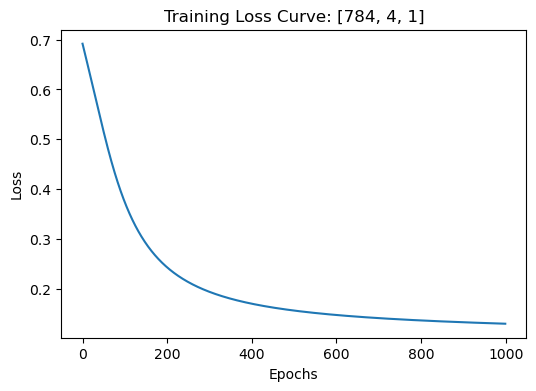

Train Accuracy: 95.76%
Train Precision: 96.60%
Train Recall: 94.85%
Train F1-score: 95.72%


Test Accuracy: 94.39%
Test Precision: 94.94%
Test Recall: 93.79%
Test F1-score: 94.36%


Validate Accuracy: 93.11%
Validate Precision: 93.17%
Validate Recall: 93.03%
Validate F1-score: 93.10%

Training network with layers: [784, 6, 3, 1]
Epoch 0 | Train Loss: 0.6951 | Val Loss: 0.6951
Epoch 200 | Train Loss: 0.6927 | Val Loss: 0.6927
Epoch 400 | Train Loss: 0.6900 | Val Loss: 0.6902
Epoch 600 | Train Loss: 0.6692 | Val Loss: 0.6702
Epoch 800 | Train Loss: 0.5004 | Val Loss: 0.5075


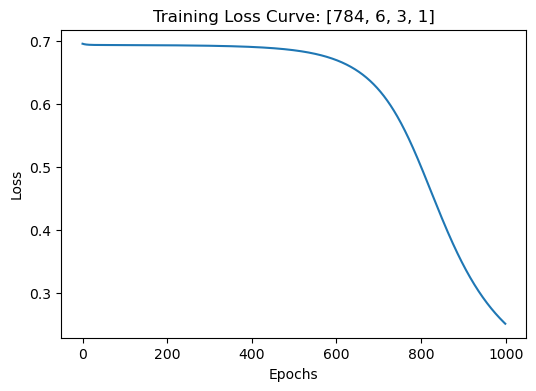

Train Accuracy: 93.61%
Train Precision: 96.25%
Train Recall: 90.76%
Train F1-score: 93.42%


Test Accuracy: 92.80%
Test Precision: 94.91%
Test Recall: 90.45%
Test F1-score: 92.63%


Validate Accuracy: 91.89%
Validate Precision: 93.54%
Validate Recall: 90.00%
Validate F1-score: 91.74%

Training network with layers: [784, 256, 128, 64, 1]
Epoch 0 | Train Loss: 0.7092 | Val Loss: 0.7102
Epoch 200 | Train Loss: 0.6879 | Val Loss: 0.6892
Epoch 400 | Train Loss: 0.6663 | Val Loss: 0.6684
Epoch 600 | Train Loss: 0.4231 | Val Loss: 0.4339
Epoch 800 | Train Loss: 0.1888 | Val Loss: 0.2045


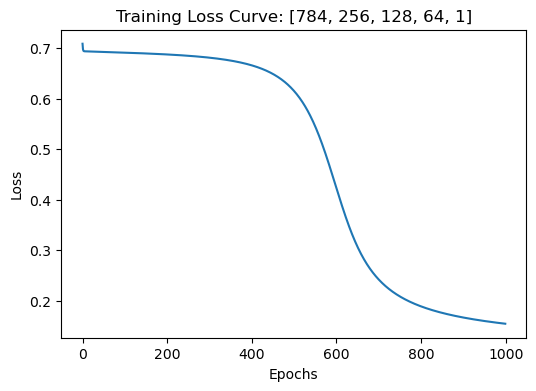

Train Accuracy: 94.39%
Train Precision: 95.83%
Train Recall: 92.83%
Train F1-score: 94.30%


Test Accuracy: 93.94%
Test Precision: 94.75%
Test Recall: 93.03%
Test F1-score: 93.88%


Validate Accuracy: 92.88%
Validate Precision: 93.54%
Validate Recall: 92.12%
Validate F1-score: 92.82%


In [67]:
layer_configs = [
    [X_train.shape[0], 4, 1],           
    [X_train.shape[0], 6, 3, 1],        
    [X_train.shape[0], 256, 128, 64, 1]
]


for layers in layer_configs:
    print(f"\nTraining network with layers: {layers}")
    parameters, losses, val_losses = train_deep_network(X_train, Y_train, X_val, Y_val, layers, lr=0.1, epochs=1000, lambda_l2=0.01)
    
    # Plot training loss
    plt.figure(figsize=(6,4))
    plt.plot(losses)
    plt.title(f"Training Loss Curve: {layers}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()
    
    # Predictions
    pred_train = predict_deep(X_train, parameters)
    pred_val   = predict_deep(X_val, parameters)
    pred_test  = predict_deep(X_test, parameters)

    DNN_train_accuracy, DNN_train_precision, DNN_train_recall, DNN_train_f1 = evaluate(Y_train, pred_train)
    DNN_test_accuracy, DNN_test_precision, DNN_test_recall, DNN_test_f1 = evaluate(Y_test, pred_test)
    DNN_val_accuracy, DNN_val_precision, DNN_val_recall, DNN_val_f1 = evaluate(Y_val, pred_val)

    print(f"Train Accuracy: {DNN_train_accuracy*100:.2f}%")
    print(f"Train Precision: {DNN_train_precision*100:.2f}%")
    print(f"Train Recall: {DNN_train_recall*100:.2f}%")
    print(f"Train F1-score: {DNN_train_f1*100:.2f}%")
    print("\n")
    print(f"Test Accuracy: {DNN_test_accuracy*100:.2f}%")
    print(f"Test Precision: {DNN_test_precision*100:.2f}%")
    print(f"Test Recall: {DNN_test_recall*100:.2f}%")
    print(f"Test F1-score: {DNN_test_f1*100:.2f}%")
    print("\n")
    print(f"Validate Accuracy: {DNN_val_accuracy*100:.2f}%")
    print(f"Validate Precision: {DNN_val_precision*100:.2f}%")
    print(f"Validate Recall: {DNN_val_recall*100:.2f}%")
    print(f"Validate F1-score: {DNN_val_f1*100:.2f}%")
    

In [68]:
pred_train = predict_deep(X_train, params_deep)
pred_val   = predict_deep(X_val, params_deep)
pred_test  = predict_deep(X_test, params_deep)


print("Train Accuracy:", accuracy(Y_train, pred_train))
print("Validation Accuracy:", accuracy(Y_val, pred_val))
print("Test Accuracy:", accuracy(Y_test, pred_test))

NameError: name 'params_deep' is not defined